In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


In [2]:
#load data
#we read the csv file into a dataframe and look at the first few rows.

In [3]:
#load data

url_train= "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df=pd.read_csv(url_train)

#show first 5 rows to see the data
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Phase 3: Analyse, Visualise & Report – Titanic Dataset

In [5]:
# Step 1: Histograms & KDEs

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[["Age_scaled", "Fare_scaled"]] = scaler.fit_transform(df[["Age", "Fare"]])

In [7]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Age_scaled',
       'Fare_scaled'],
      dtype='object')


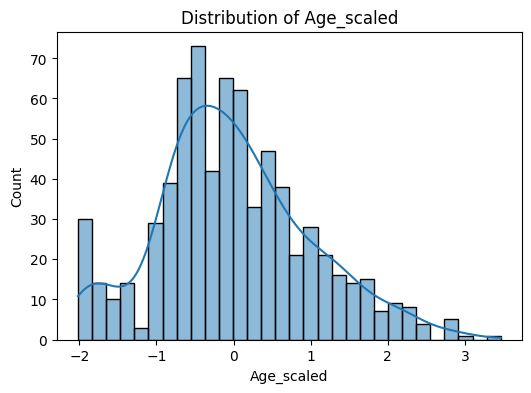

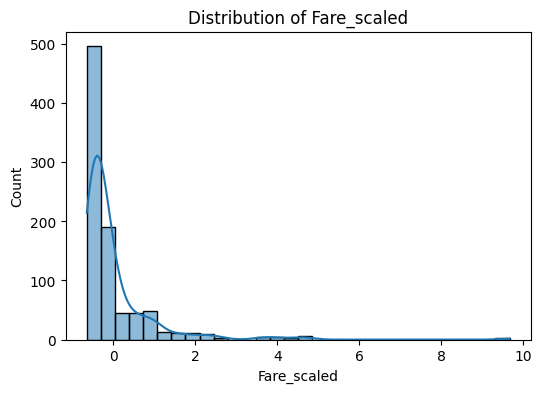

In [8]:
# We examine the distribution of numerical features to understand their shape
numeric_cols = ["Age_scaled", "Fare_scaled"]

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [9]:
# Step 2: Grouped Boxplots

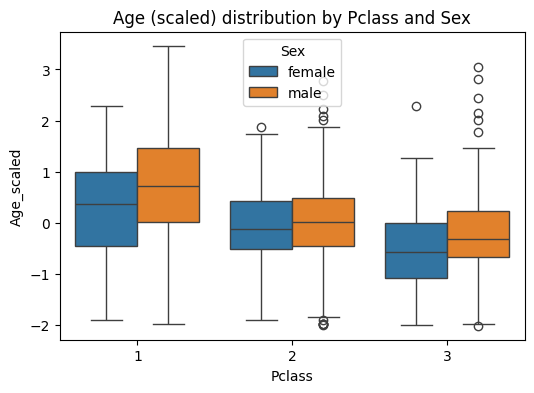

In [11]:
# Compare Age (scaled) across passenger class and gender
plt.figure(figsize=(6,4))
sns.boxplot(x="Pclass", y="Age_scaled", hue="Sex", data=df)
plt.title("Age (scaled) distribution by Pclass and Sex")
plt.show()

In [12]:
# Step 3: Correlation Heatmap

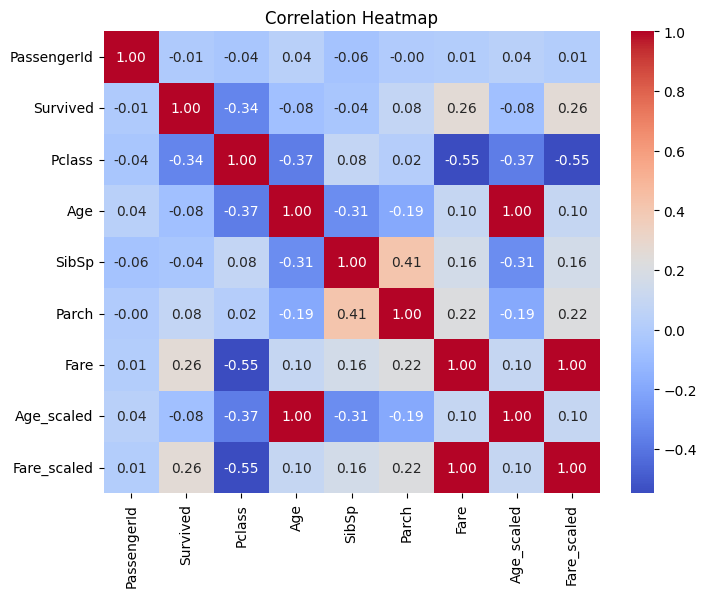

In [13]:
# Select only numeric columns to avoid errors
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [14]:
# Step 4: Scatter Plot

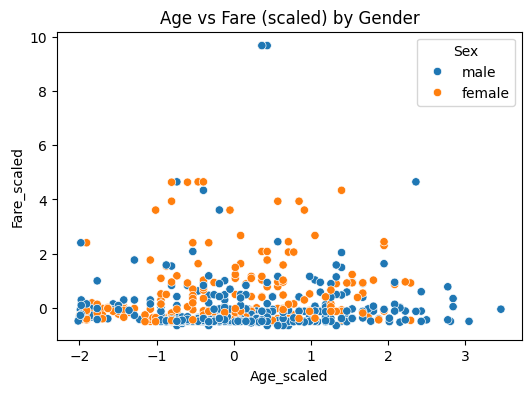

In [16]:
# Scatter plot to explore relationship between Age and Fare (scaled)
plt.figure(figsize=(6,4))
sns.scatterplot(x="Age_scaled", y="Fare_scaled", hue="Sex", data=df)
plt.title("Age vs Fare (scaled) by Gender")
plt.show()

In [17]:
# Step 5: GroupBy Summary

In [18]:
# Calculate average Fare (scaled) per class
grouped = df.groupby("Pclass")["Fare_scaled"].mean()
print(grouped)

Pclass
1    1.046007
2   -0.232395
3   -0.373069
Name: Fare_scaled, dtype: float64


In [19]:
# Step 6: Basic Math Checks

In [20]:
# Compute mean and std manually
values = df["Fare_scaled"].values

mean_val = np.sum(values) / len(values)
std_val = np.sqrt(np.sum((values - mean_val)**2) / len(values))

print("Mean:", mean_val)
print("Std:", std_val)

Mean: 3.987332972840069e-18
Std: 1.0


In [21]:
# Step 7: Probability

In [22]:
# Probability that Fare_scaled is above 0 (since scaled mean ≈ 0)
prob = (df["Fare_scaled"] > 0).sum() / len(df)
print("Probability Fare_scaled > 0:", prob)

Probability Fare_scaled > 0: 0.23681257014590348


In [23]:
# Step 8: Insights

In [24]:
# You can write a one-paragraph insight for each chart, e.g.:
# "Passengers in 1st class generally paid higher fares than 3rd class, with a few extreme values."
# "Age distribution shows most passengers are adults between 18-60, with few seniors and children."
# "Correlation heatmap indicates Fare is strongly correlated with Pclass_x_Age and Fare_per_Age."
# Include these insights in your report along with at least one chart.